In [1]:
import numpy as np
import matplotlib.pyplot as plt

from struphy import (
    BoundaryParameters,
    LoadingParameters,
    SortingParameters,
    domains,
    perturbations,
)
from struphy.fields_background.equils import ConstantVelocity
from struphy.pic.particles import ParticlesSPH


In [2]:
#gaussian_1d = lambda x,h: 3.0 * np.exp(-9.0*x**2 / h**2) / (np.sqrt(np.pi) * h)

In [3]:
from scipy.integrate import quad 
from struphy.pic.sph_smoothing_kernels import gaussian_1d

def rho_conv(x, rho):
    integrand = lambda y: gaussian_1d(x - y,0., 0., h1, h2, h3) * rho(y, 0, 0)
    ret = quad(integrand, 0.0, 1.0, points=(x,))
    return ret[0]


In [4]:
def eval_rho_Nh(particles, x, kernel):
    valid = particles.valid_mks
    weights = particles.markers[valid, particles.index["weights"]]
    xpos = particles.markers[valid, 0]
    
    summand = weights * np.array([kernel(x-y,0.,0., h1, h2,h3) for y in xpos])
    return summand.sum()
   



In [ ]:
domain = domains.Cuboid(l1=0.0, r1=1.0, l2=0.0, r2=1.0, l3=0.0, r3=1.0)
background = ConstantVelocity(n=2., density_profile="constant")
background.domain = domain
pert = {"n": perturbations.ModesCos(ls=(1,), amps=(1.0,))}
#{} 

# ---------- 2. Discretization ----------

boxes_per_dim = (24, 1, 1)
n_pts = 100
x1 = np.linspace(0.,1.,n_pts)
x2 = np.array([0.])
x3 = np.array([0.])
xx1, xx2, xx3 = np.meshgrid(x1, x2,x3)
h1 = 1./boxes_per_dim[0]; h2 = 1./boxes_per_dim[1]; h3 = 1./boxes_per_dim[2]
boundary_params = BoundaryParameters(bc_sph=("periodic", "periodic", "periodic"))
sorting_params = SortingParameters(boxes_per_dim=boxes_per_dim)
ppb_list = [4**k for k in range(2,9)]
# Exact density
rho_exact = lambda e1, e2, e3: 2.0 + np.cos(2 * np.pi * e1)#* np.ones_like(e1)
x_plot = xx1.squeeze()
rho_conv_grid = np.array([rho_conv(x, rho_exact) for x in x_plot])
N_list = np.array(ppb_list) * boxes_per_dim[0]

err_list = []
for ppb in ppb_list:
    loading_params = LoadingParameters(ppb=ppb, loading="tesselation")

    particles = ParticlesSPH(
        comm_world=None,
        loading_params=loading_params,
        boundary_params=boundary_params,
        sorting_params=sorting_params,
        bufsize=1.0,
        domain=domain,
        background=background,
        perturbations=pert,
        n_as_volume_form=True,
    )
    particles.draw_markers(sort=False)
    particles.initialize_weights()

    # rho_sph = particles.eval_density(
    #     xx1, xx2, xx3,
    #     h1=h1, h2=h2, h3=h3,
    #     kernel_type="gaussian_1d",
    #     derivative=0, 
    #     fast=False
    # ).squeeze()
    rho_sph = np.array([eval_rho_Nh(particles, x, gaussian_1d) for x in x_plot])

    err = np.max(np.abs(rho_sph - rho_conv_grid))
    err_list.append(err)



In [20]:
print([4**k for k in range(2,9)])

[16, 64, 256, 1024, 4096, 16384, 65536]


In [21]:
24*65536

1572864

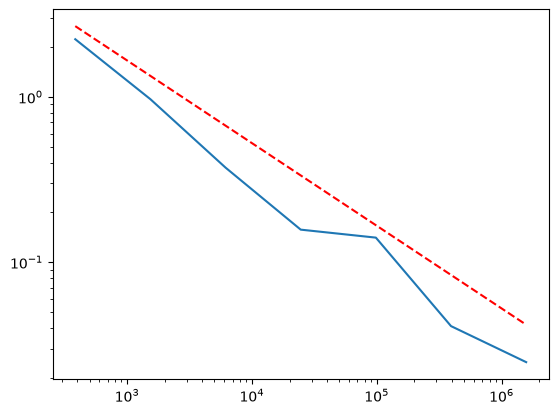

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.loglog(N_list, err_list)
C2 = 1.2*err_list[0]*N_list[0]**.5
ax.loglog(N_list, C2/N_list**.5, 'r--', label='second order')

<>:11: SyntaxWarning: invalid escape sequence '\i'
<>:11: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_130809/3131519302.py:11: SyntaxWarning: invalid escape sequence '\i'
  ax.set_ylabel('Absolute $L_\infty$ error', fontsize=17)  # ≥17


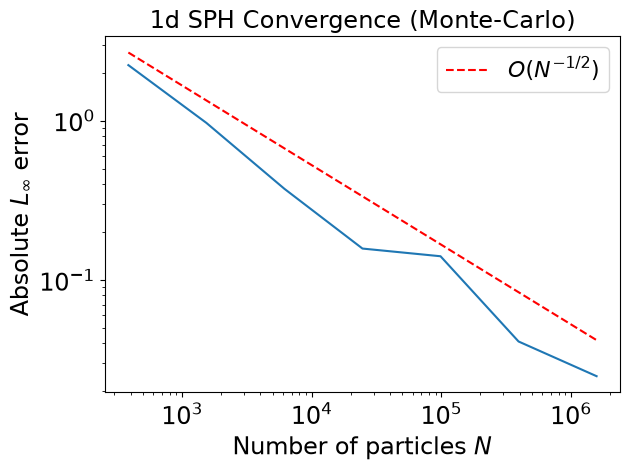

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.loglog(N_list, err_list)
C2 = 1.2*err_list[0]*N_list[0]**(.5)
ax.loglog(N_list, C2/N_list**(.5), 'r--', label='$O(N^{-1/2})$')


# ---------- Axis labels and font size settings ----------
# Axis labels (titles on axes)
ax.set_xlabel('Number of particles $N$', fontsize=17)   # ≥17
ax.set_ylabel('Absolute $L_\infty$ error', fontsize=17)  # ≥17

# Tick labels (numbers on axes)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.tick_params(axis='both', which='minor', labelsize=14)  # optional, minor ticks can be smaller

# Legend (if you want to show it)
ax.legend(fontsize=16)
ax.set_title('1d SPH Convergence (Monte-Carlo)', fontsize = 17)

# Optional: figure title (not required but if you want it)
# ax.set_title('Convergence plot', fontsize=18)

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:24: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_130809/500505530.py:24: SyntaxWarning: invalid escape sequence '\i'
  ax.set_ylabel('Absolute $L_\infty$ error', fontsize=17)


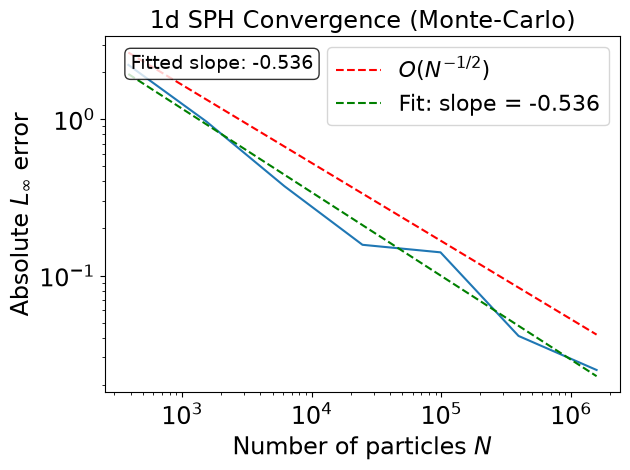

In [19]:
import numpy as np  # Ensure numpy is imported

fig = plt.figure()
ax = fig.add_subplot(111)
ax.loglog(N_list, err_list)

# Reference line with slope -1/2
C2 = 1.2 * err_list[0] * N_list[0]**0.5
ax.loglog(N_list, C2 / N_list**0.5, 'r--', label='$O(N^{-1/2})$')

# --- Fit the data to get the actual slope ---
logN = np.log(N_list)
logerr = np.log(err_list)
# Linear fit: logerr = m * logN + b
m, b = np.polyfit(logN, logerr, 1)
# Plot the fitted line (power law)
ax.loglog(N_list, np.exp(b) * N_list**m, 'g--', label=f'Fit: slope = {m:.3f}')
# Annotate the slope value on the plot (top-left corner)
ax.text(0.05, 0.95, f'Fitted slope: {m:.3f}', transform=ax.transAxes,
        fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ---------- Axis labels and font size settings ----------
ax.set_xlabel('Number of particles $N$', fontsize=17)
ax.set_ylabel('Absolute $L_\infty$ error', fontsize=17)

ax.tick_params(axis='both', which='major', labelsize=17)
ax.tick_params(axis='both', which='minor', labelsize=14)

ax.legend(fontsize=16)
ax.set_title('1d SPH Convergence (Monte-Carlo)', fontsize=17)

plt.tight_layout()
plt.show()

In [9]:
# ---------- Axis labels and font size settings ----------
# Axis labels (titles on axes)
ax.set_xlabel('Number of particles $N$', fontsize=18)   # ≥17
ax.set_ylabel('Maximum error $L_\infty$', fontsize=18)  # ≥17

# Tick labels (numbers on axes)
ax.tick_params(axis='both', which='major', labelsize=17)
ax.tick_params(axis='both', which='minor', labelsize=14)  # optional, minor ticks can be smaller

# Legend (if you want to show it)
ax.legend(fontsize=17)

# Optional: figure title (not required but if you want it)
# ax.set_title('Convergence plot', fontsize=18)

# Adjust layout to avoid clipping
plt.tight_layout()

# Show the plot
plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_130809/3361037963.py:4: SyntaxWarning: invalid escape sequence '\i'
  ax.set_ylabel('Maximum error $L_\infty$', fontsize=18)  # ≥17


<Figure size 640x480 with 0 Axes>

In [10]:
summing over all particles without sortig, not implementing any bc and kernel is a gaussian, which has infintie support 

SyntaxError: invalid syntax (330424862.py, line 1)

In [ ]:
signal/ noise ration 

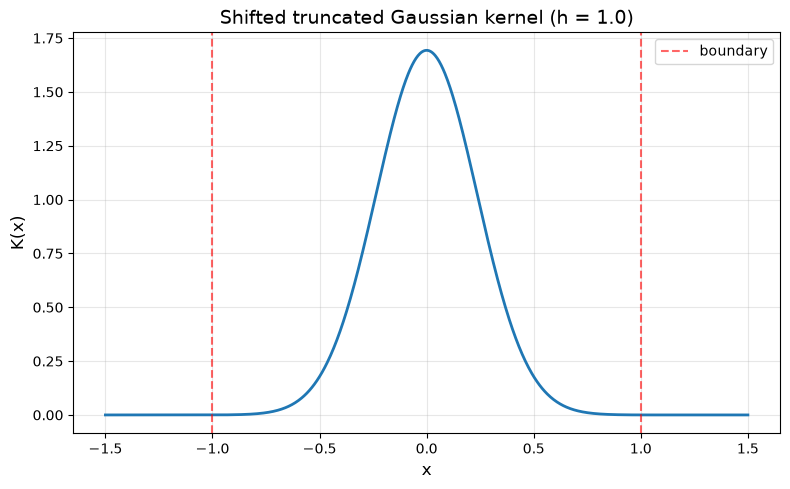

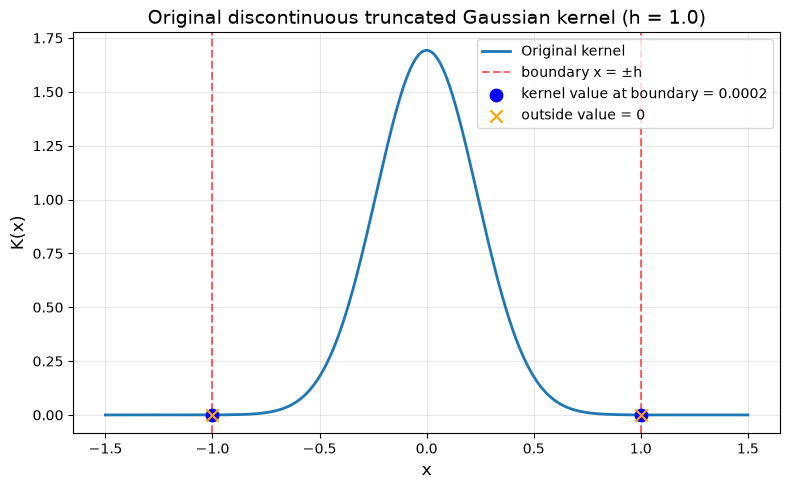